# **6. Regresión Local.**

Temas selectos de aprendizaje de máquina \
Ana Luisa Llamas Martinez

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm

from ISLP import load_data


In [3]:
Wage = load_data("Wage")

age = Wage["age"]
wage = Wage["wage"]

## 6.5 Primer ajuste LOWESS.

In [4]:
lowess = sm.nonparametric.lowess

fit_05 = lowess(
    wage,
    age,
    frac=0.5
)

In [5]:
fit_05.shape

(3000, 2)

In [6]:
x_lowess = fit_05[:,0]
y_lowess = fit_05[:,1]

## 6.6 Visualización del ajuste.

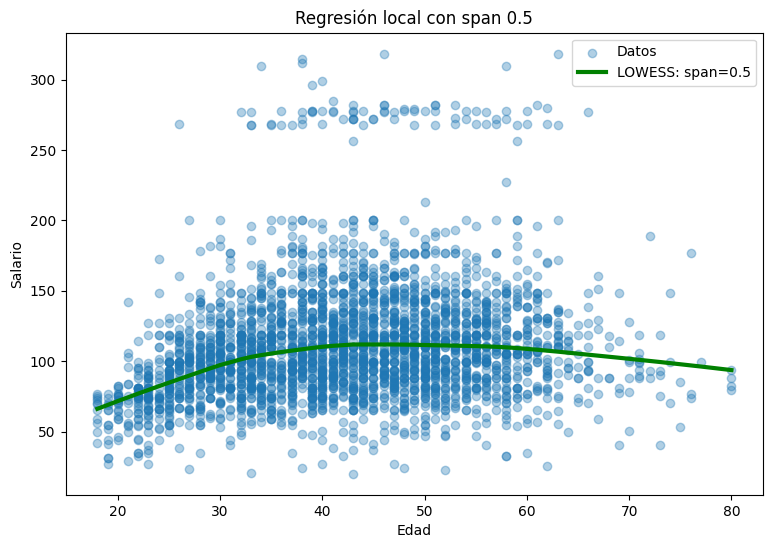

In [7]:
plt.figure(figsize = (9, 6))

plt.scatter(age, wage, alpha = 0.35, label = "Datos")

plt.plot(x_lowess, y_lowess, linewidth = 3, color = "green", label = "LOWESS: span=0.5")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Regresión local con span 0.5")
plt.legend()
plt.show()

## 6.7 El parámetro frac.

In [8]:
n = len(Wage)

for span in [0.2, 0.5, 0.7]:
    k = int(np.ceil(span*n))
    print(f"span = {span} : aprox {k} observaciones")

span = 0.2 : aprox 600 observaciones
span = 0.5 : aprox 1500 observaciones
span = 0.7 : aprox 2100 observaciones


In [9]:
spans = [0.2, 0.5, 0.7]
fit = {}
for span in spans:
    fit[span] = lowess(wage, age, frac = span)
    

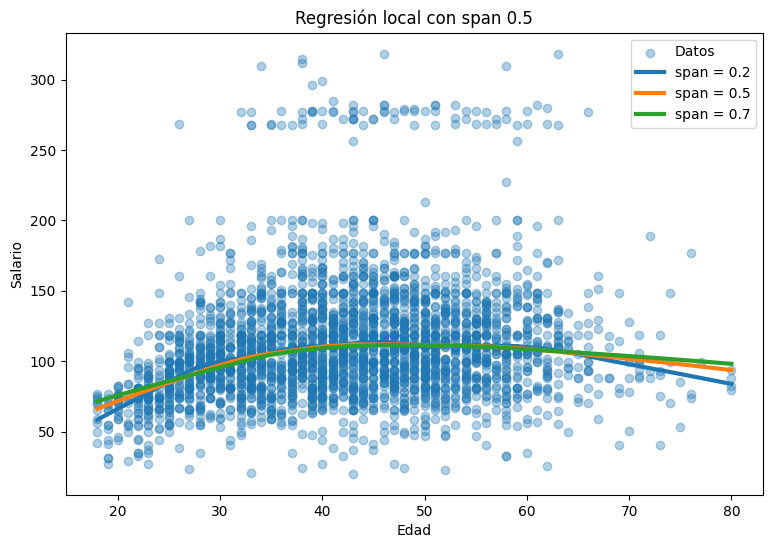

In [10]:
plt.figure(figsize = (9, 6))

plt.scatter(age, wage, alpha = 0.35, label = "Datos")

for span in spans:
    fitted = fit[span]
    plt.plot(fitted[:,0], fitted[:,1], linewidth = 3, label = f"span = {span}")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Regresión local con span 0.5")
plt.legend()
plt.show()

## 6.9 ¿Qué significa realmente hacer un ajuste local?

In [11]:
x0 = 40
span = 0.2
n = len(age)
k = int(np.ceil(span*n))
k

600

## 6.10 Calcular la distancia respecto a $x_0$.

In [12]:
distance = np.abs(age.to_numpy() - x0)
nearest_idx = np.argsort(distance)[:k]

In [13]:
nearest_idx

array([2962, 1444, 1507, 1086, 2911, 2893, 2896,   96, 2867, 2873, 1244,
       2348, 1254,  326,  330, 2612, 2619, 2357, 1734, 1265,  312, 2336,
       2013, 2645, 1526, 1531, 2189, 2138, 2118, 2442, 2444, 2425, 2428,
        961, 2310, 1713,  603, 1882, 2432,  466, 1426, 2856, 2861, 1397,
        587, 2372,  998, 2400,  577,  948, 2285, 1285,  394, 1231,  399,
       1170, 2513, 1156, 2735,  246, 1310, 1667,  255, 2707, 1282,  894,
        897, 2745,  231, 1645,  676, 2841,  148,  866, 2228, 2233, 1780,
       2398, 2555, 1778,  704, 2257, 2271,  549, 1908,  842, 1598, 1378,
        713, 2244,  199,  173, 2792, 2799,  728,  734, 2784,  193, 1331,
       2488, 1845, 1846, 1864, 1126, 2624, 2982,   21,   23, 2980, 2921,
         74, 2942, 1490, 1470,   13, 2925, 2914,   63, 2937,   44,  505,
       1141, 1110,  489, 1841,  481, 1520,  807, 2174, 2170, 1492,  187,
        853,  748,  722, 2256, 1605,  182,  176, 1921, 1039, 2393,  405,
       2576, 2575,  208, 1356, 1354, 2083,  877, 22

In [14]:
age_local = age.to_numpy()[nearest_idx]
wage_local = wage.to_numpy()[nearest_idx]

distance_local = distance[nearest_idx]

## 6.11 Visualizar el vecindario.

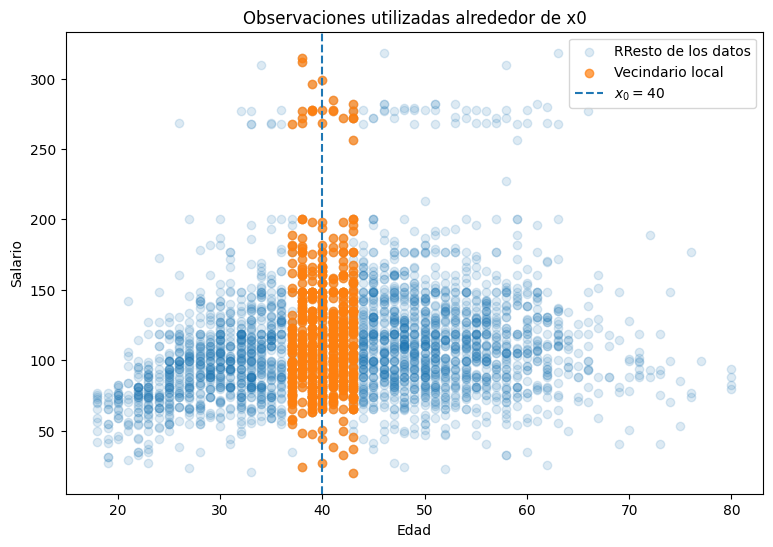

In [15]:
plt.figure(figsize = (9,6))

plt.scatter(age, wage, alpha = 0.15, label = "RResto de los datos")

plt.scatter(age_local, wage_local, alpha = 0.7, label = "Vecindario local")

plt.axvline(x=x0, linestyle = "--", label = r"$x_0=40$")
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Observaciones utilizadas alrededor de x0")
plt.legend()
plt.show()

## 6.12 Construcción de pesos locales.

In [16]:
d_max = distance_local.max()
u = distance_local/d_max
weights = (1-u**3)**3

## 6.13 Distancia y peso.

In [17]:
local_info = pd.DataFrame({"age" : age_local, 
                           "wage" : wage_local, 
                           "distance": distance_local, 
                           "weight" : weights})

local_info = local_info.sort_values("distance")
local_info.head(15)

,age,wage,distance,weight
0,40,97.493294,0,1.0
1,40,111.720849,0,1.0
2,40,138.639172,0,1.0
3,40,82.679637,0,1.0
4,40,133.232351,0,1.0
5,40,299.262977,0,1.0
6,40,73.775743,0,1.0
7,40,98.599344,0,1.0
8,40,130.982177,0,1.0
9,40,112.648896,0,1.0


In [18]:
local_info.tail(15)

,age,wage,distance,weight
585,37,75.043154,3,0.0
586,37,96.370653,3,0.0
587,43,281.745971,3,0.0
588,43,36.673704,3,0.0
589,43,167.706576,3,0.0
590,37,84.718390,3,0.0
591,37,84.450254,3,0.0
592,43,109.833986,3,0.0
593,43,109.833986,3,0.0
594,43,73.775743,3,0.0


## 6.14 Visualizar la función de pesos.

C:\Users\analu\AppData\Local\Temp\ipykernel_36240\109802621.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


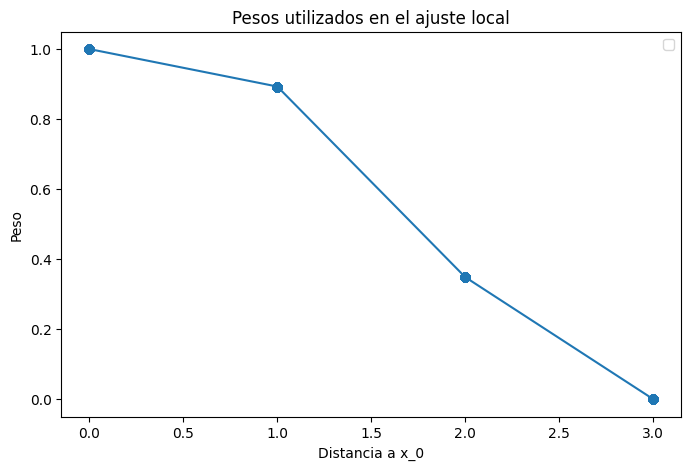

In [19]:
order = np.argsort(distance_local)

plt.figure(figsize=(8,5))

plt.plot(distance_local[order], weights[order], marker = "o")

plt.xlabel("Distancia a x_0")
plt.ylabel("Peso")
plt.title("Pesos utilizados en el ajuste local")
plt.legend()
plt.show()

## 6.15 Visualizar los pesos sobre los datos.

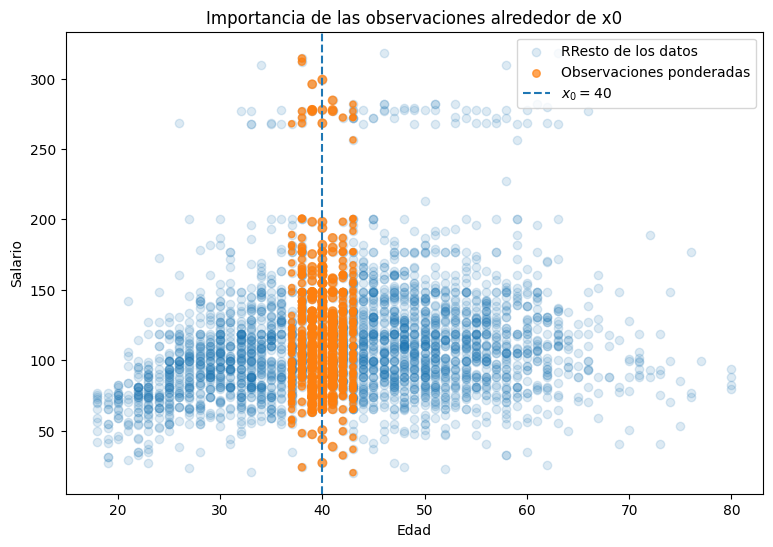

In [20]:
plt.figure(figsize = (9,6))

plt.scatter(age, wage, alpha = 0.15, label = "RResto de los datos")

plt.scatter(age_local, wage_local, s=20+18*weights, alpha = 0.7, label = "Observaciones ponderadas")

plt.axvline(x=x0, linestyle = "--", label = r"$x_0=40$")
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Importancia de las observaciones alrededor de x0")
plt.legend()
plt.show()

## 6.16 Ajustar una regresión lineal ponderada.

In [21]:
X_local = sm.add_constant(age_local)

local_model = sm.WLS(wage_local, X_local, weights = weights).fit()

In [22]:
local_model.params

array([209.24639572,  -2.28423526])

## 6.17 Predicción en $x_0$.

In [23]:
beta0, beta1 = local_model.params

prediction_x0 = beta0 + beta1 *x0

prediction_x0

np.float64(117.87698526397844)

## 6.18 Visualizar la recta local.

In [24]:
recta = beta0 + beta1 *age_local


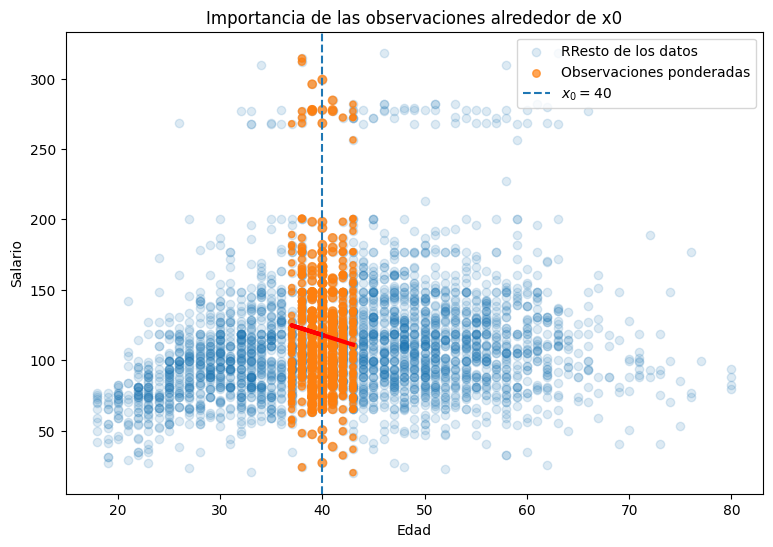

In [25]:
plt.figure(figsize = (9,6))

plt.scatter(age, wage, alpha = 0.15, label = "RResto de los datos")

plt.scatter(age_local, wage_local, s=20+18*weights, alpha = 0.7, label = "Observaciones ponderadas")

plt.plot(age_local, recta, linewidth = 3, color = "red")

plt.axvline(x=x0, linestyle = "--", label = r"$x_0=40$")
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Importancia de las observaciones alrededor de x0")
plt.legend()
plt.show()

## 6.20 Comparación con una regresión lineal global.

In [26]:
X_global = sm.add_constant(age)
global_model = sm.OLS(wage, X_global).fit()

In [27]:
age_grid = np.linspace(age.min(), age.max(), 500)

X_grid = sm.add_constant(age_grid)
global_pred = global_model.predict(X_grid)

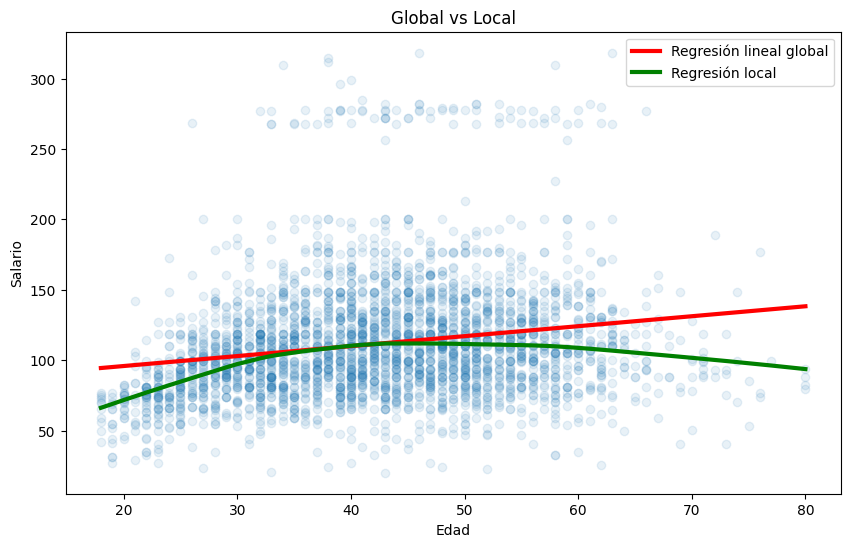

In [28]:
plt.figure(figsize = (10,6))

plt.scatter(age, wage, alpha = 0.1)

plt.plot(age_grid, global_pred, linewidth = 3, color = "red", label = "Regresión lineal global")

plt.plot(fit_05[:,0], fit_05[:,1], linewidth = 3, color = "green", label = "Regresión local")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Global vs Local")
plt.legend()
plt.show()

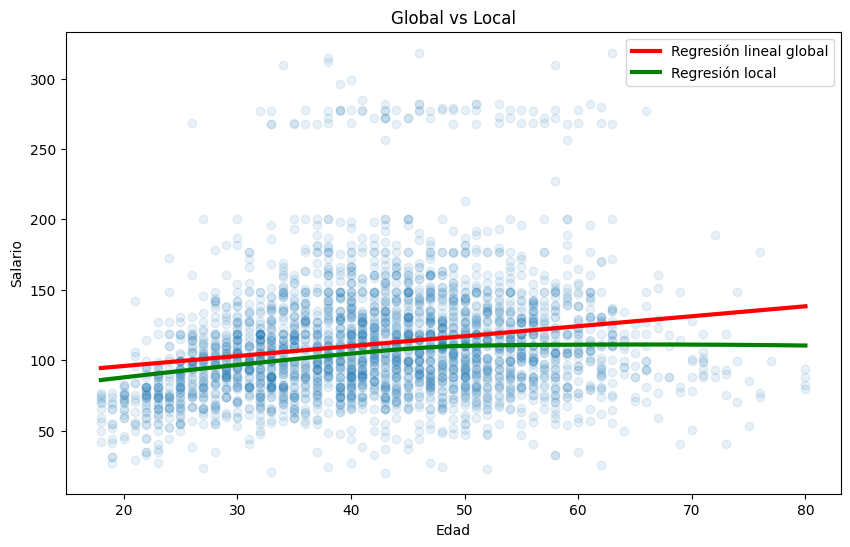

In [29]:
fit_lowess = lowess(wage, age, frac = 0.999)

plt.figure(figsize = (10,6))

plt.scatter(age, wage, alpha = 0.1)

plt.plot(age_grid, global_pred, linewidth = 3, color = "red", label = "Regresión lineal global")

plt.plot(fit_lowess[:,0], fit_lowess[:,1], linewidth = 3, color = "green", label = "Regresión local")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Global vs Local")
plt.legend()
plt.show()

## 6.21 ¿Qué ocurre con spans muy pequeños?

In [30]:
small_span = lowess(wage, age, frac = 0.05)
smooth_span = lowess(wage, age, frac=0.7)

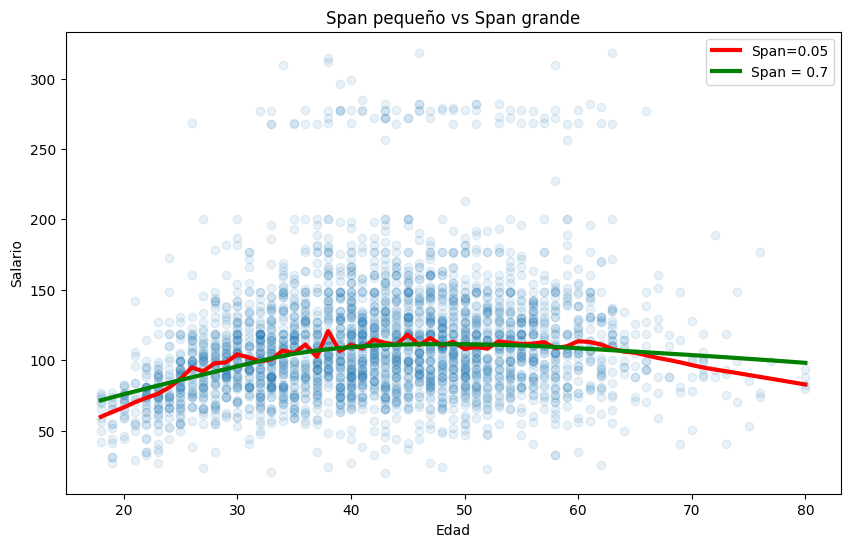

In [31]:
fit_lowess = lowess(wage, age, frac = 0.999)

plt.figure(figsize = (10,6))

plt.scatter(age, wage, alpha = 0.1)

plt.plot(small_span[:,0], small_span[:,1], linewidth = 3, color = "red", label = "Span=0.05")
plt.plot(smooth_span[:,0], smooth_span[:,1], linewidth = 3, color = "green", label = "Span = 0.7")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Span pequeño vs Span grande")
plt.legend()
plt.show()

## 6.23 Una consideración importante: predecir con LOWESS.

In [32]:
fit_grid = lowess(wage, age, frac = 0.5, xvals = age_grid)

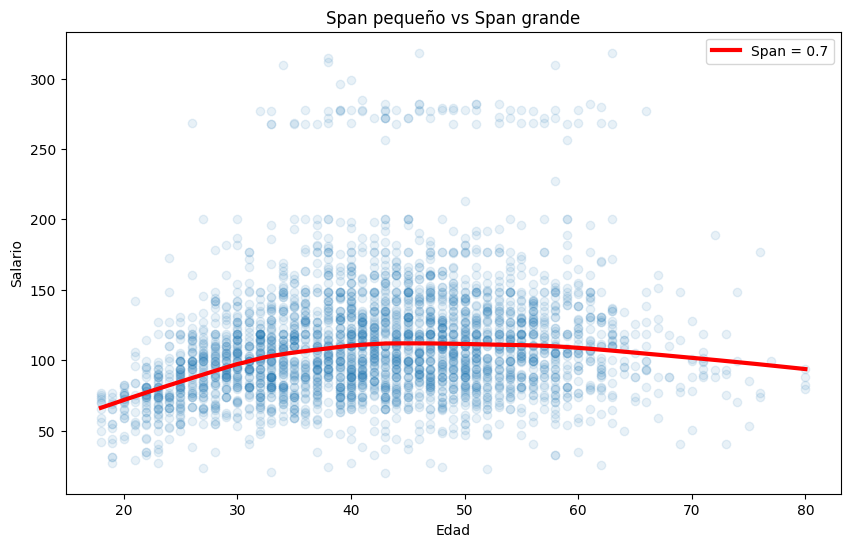

In [33]:
plt.figure(figsize = (10,6))

plt.scatter(age, wage, alpha = 0.1)

plt.plot(age_grid, fit_grid, linewidth = 3, color = "red", label = "Span = 0.7")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Span pequeño vs Span grande")
plt.legend()

## 6.24 Selección del span mediante validación cruzada.

In [34]:
candidate_spans = np.linspace(0.1, 0.8, num=8)

In [35]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [36]:
kf = KFold(n_splits=5, shuffle = True, random_state=123)

X = age.to_numpy()
y = wage.to_numpy()

In [37]:
cv_results = []

for span in candidate_spans:
    fold_mse = []
    for train_idx, test_idx in kf.split(X):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_test = X[test_idx]
        y_test = y[test_idx]
        y_pred = lowess(y_train, X_train, frac=span, xvals = X_test)
        mse = mean_squared_error(y_test, y_pred)
        fold_mse.append(mse)

    cv_results.append({"span": span, "MSE": np.mean(fold_mse)})

In [38]:
cv_results = pd.DataFrame(cv_results)
cv_results

,span,MSE
0,0.1,1635.867703
1,0.2,1633.581162
2,0.3,1634.965435
3,0.4,1638.400080
4,0.5,1642.713358
5,0.6,1647.810688
6,0.7,1653.492066
7,0.8,1660.757365


## 6.25 Visualizar el error de validación.

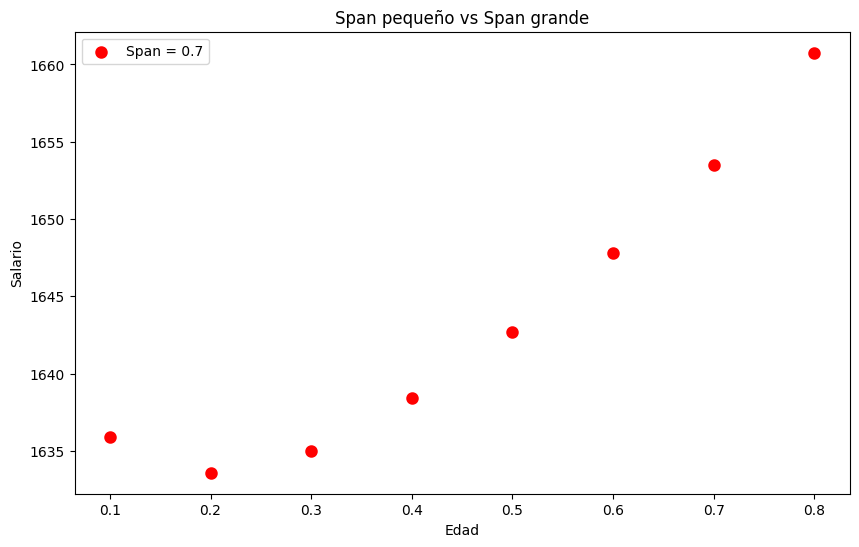

In [39]:
plt.figure(figsize = (10,6))

plt.scatter(cv_results["span"], cv_results["MSE"], linewidth = 3, color = "red", label = "Span = 0.7")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Span pequeño vs Span grande")
plt.legend()

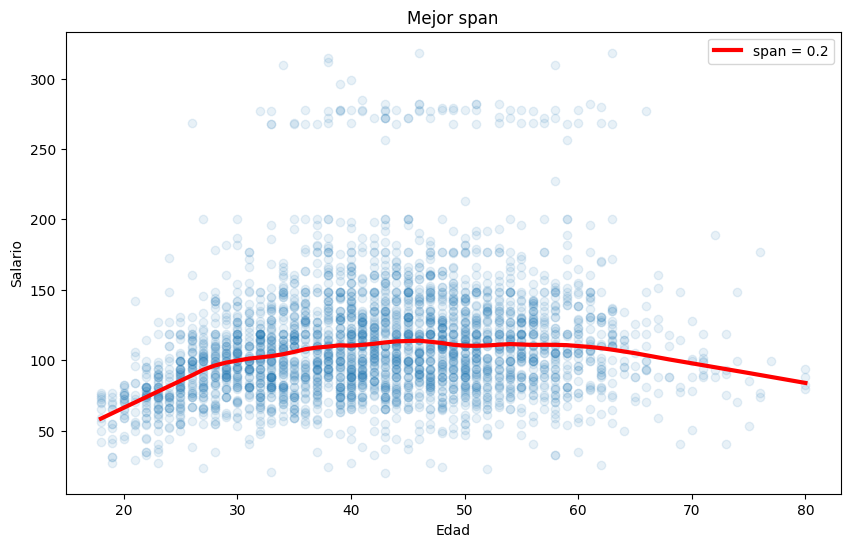

In [40]:
fit_02 = lowess(wage, age, frac = 0.2)

plt.figure(figsize = (10,6))

plt.scatter(age, wage, alpha = 0.1)


plt.plot(fit_02[:,0], fit_02[:,1], linewidth = 3, color = "red", label = "span = 0.2")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Mejor span")
plt.legend()
plt.show()

## EJERCICIOS

**6.28.1 Ejercicio 1. Efecto del span** Ajusta modelos LOWESS utilizando

$$
    s=0.1, s=0.3, s=0.5, s=0.7, s=0.9
$$

Representa todos los ajustes sobre la misma gráfica.

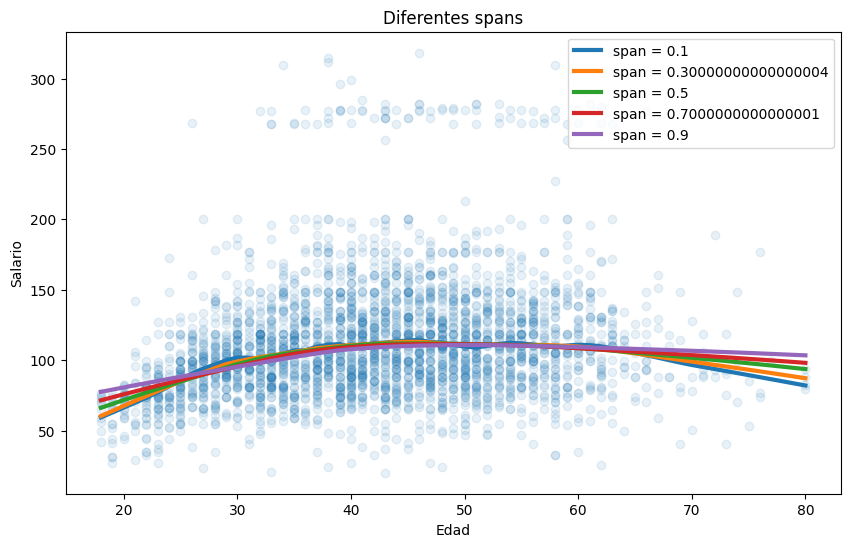

In [41]:
candidate_spans1 = np.linspace(0.1, 0.9, num=5)


plt.figure(figsize = (10,6))

plt.scatter(age, wage, alpha = 0.1)

for span in candidate_spans1:
    fit_lowess1 = lowess(wage, age, frac = span)
    plt.plot(fit_lowess1[:,0], fit_lowess1[:,1], linewidth = 3, label = f"span = {span}")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Diferentes spans")
plt.legend()
plt.show()


Responde:

- ¿Cuál produce la curva más flexible?

El span de 0.1
- ¿Cuál produce la curva más suave?

El span de 0.9
- ¿En qué regiones del dominio observas mayores diferencias entre los modelos?

En los extremos.

**6.28.2 Ejercicio 2. Un ajuste local.** Repite el procedimiento manual para

$$
x_0 = 55
$$

utilizando

$$
s = 0.2
$$

Calcula:
- el número $k$ de observaciones utilizadas;

In [42]:
x02 = 55
span2 = 0.2
n2 = len(age)
k2 = int(np.ceil(span2*n2))
print(f"Número de observaciones usadas: {k2}")

Número de observaciones usadas: 600


- las distancias respecto a $x_0$;
- los pesos tricúbicos;

In [43]:
distance2 = np.abs(age.to_numpy() - x02)
nearest_idx2 = np.argsort(distance2)[:k2]

age_local2 = age.to_numpy()[nearest_idx2]
wage_local2 = wage.to_numpy()[nearest_idx2]

distance_local2 = distance2[nearest_idx2]

In [44]:
distance2

array([37, 31, 10, ..., 28, 28,  0], shape=(3000,))

In [45]:
d_max2 = distance_local2.max()
u2 = distance_local2/d_max2
weights2 = (1-(u2)**3)**3

local_info2 = pd.DataFrame({"age" : age_local2, 
                           "wage" : wage_local2, 
                           "distance": distance_local2, 
                           "weight" : weights2})

local_info2 = local_info2.sort_values("distance")
local_info2.head(15)

,age,wage,distance,weight
0,55,90.481913,0,1.0
1,55,66.044694,0,1.0
2,55,118.884359,0,1.0
3,55,87.981033,0,1.0
4,55,101.824352,0,1.0
5,55,98.599344,0,1.0
6,55,127.115744,0,1.0
7,55,109.833986,0,1.0
8,55,81.283253,0,1.0
9,55,118.884359,0,1.0


In [46]:
local_info2.tail(15)

,age,wage,distance,weight
585,50,130.982177,5,0.0
586,50,141.775172,5,0.0
587,50,148.413159,5,0.0
588,50,143.134941,5,0.0
589,50,87.981033,5,0.0
590,50,148.413159,5,0.0
591,60,138.299127,5,0.0
592,50,101.824352,5,0.0
593,60,114.926522,5,0.0
594,60,128.680488,5,0.0


- la regresión lineal ponderada;
- la predicción $\hat{f}(55)$.

In [47]:
X_local2 = sm.add_constant(age_local2)

local_model2 = sm.WLS(wage_local2, X_local2, weights = weights2).fit()

In [51]:
beta02, beta12 = local_model2.params
prediction_x02 = beta02 + beta12 *x02

print(f"La predicción en x0 es: {prediction_x02}")

La predicción en x0 es: 118.0543891858652


Construye una gráfica que muestre el vecindario, los pesos y la recta local.

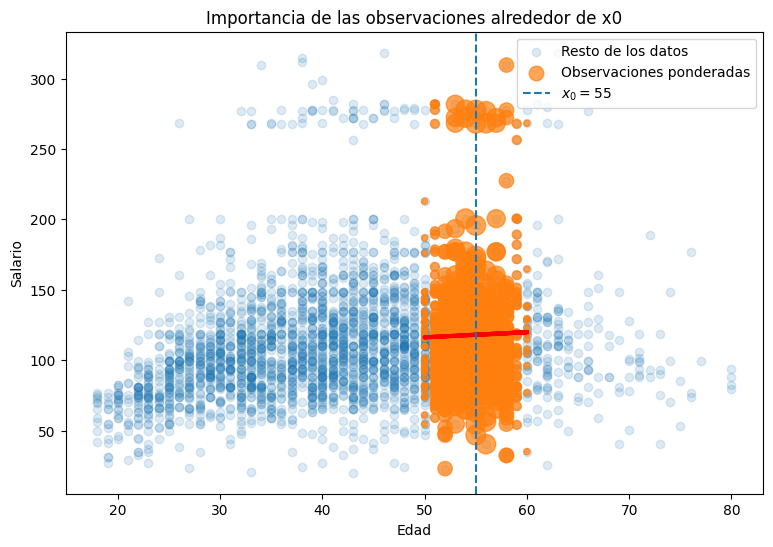

In [ ]:
beta02, beta12 = local_model2.params
prediction_x02 = beta02 + beta12 *x02
recta2 = beta02 + beta12 *age_local2

plt.figure(figsize = (9,6))

plt.scatter(age, wage, alpha = 0.15, label = "Resto de los datos")

plt.scatter(age_local2, wage_local2, s=20 + 180*weights2, alpha = 0.7, label = "Observaciones ponderadas")

plt.plot(age_local2, recta2, linewidth = 3, color = "red")

plt.axvline(x=x02, linestyle = "--", label = r"$x_0=55$")
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Importancia de las observaciones alrededor de x0")
plt.legend()
plt.show()

**6.28.3 Ejercicio 3. Cambiar el span localmente.** Mantén

$$
x_0 = 55
$$

y repite el ajuste manual utilizando

$$
s = 0.1, 0.3, 0.6.
$$

Compara las tres predicciones.

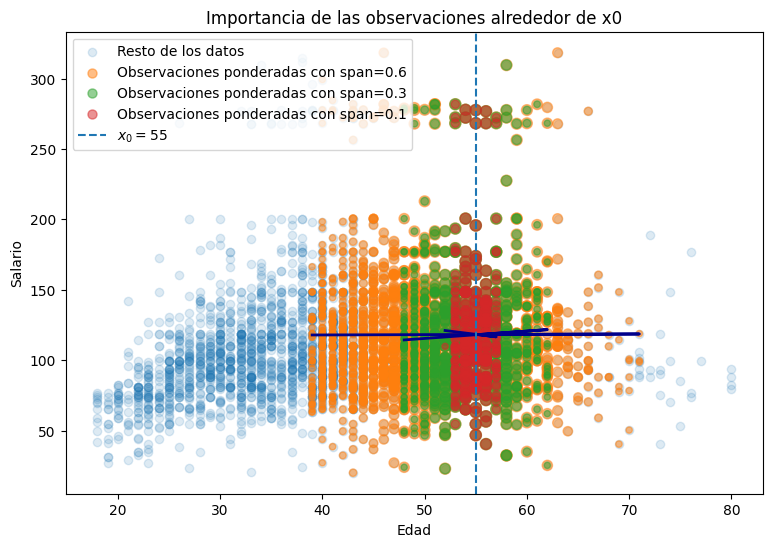

In [53]:
spans3 = [0.6, 0.3, 0.1]
x03 = 55

plt.figure(figsize = (9,6))

plt.scatter(age, wage, alpha = 0.15, label = "Resto de los datos")

for s in spans3:
    span = s
    n = len(age)
    k = int(np.ceil(span*n))

    distance = np.abs(age.to_numpy() - x03)
    nearest_idx = np.argsort(distance)[:k]

    age_local = age.to_numpy()[nearest_idx]
    wage_local = wage.to_numpy()[nearest_idx]

    distance_local = distance[nearest_idx]

    d_max = distance_local.max()
    u = distance_local/d_max
    weights = (1-(u)**3)**3

    local_info = pd.DataFrame({"age" : age_local, 
                            "wage" : wage_local, 
                            "distance": distance_local, 
                            "weight" : weights})

    local_info = local_info.sort_values("distance")

    X_local = sm.add_constant(age_local)

    local_model = sm.WLS(wage_local, X_local, weights = weights).fit()

    beta0, beta1 = local_model.params
    prediction_x0 = beta0 + beta1 *x0

    recta = beta0 + beta1 *age_local

    plt.scatter(age_local, wage_local, s=20 + 45*weights, alpha = 0.5, label = f"Observaciones ponderadas con span={span}")

    plt.plot(age_local, recta, linewidth = 2, color="darkblue")

plt.axvline(x=x03, linestyle = "--", label = r"$x_0=55$")
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Importancia de las observaciones alrededor de x0")
plt.legend()
plt.show()

In [54]:
local_agev= []
local_wagev= []
weightsv=[]
rectas = []

for s in spans3:
    span = s
    n = len(age)
    k = int(np.ceil(span*n))

    distance = np.abs(age.to_numpy() - x03)
    nearest_idx = np.argsort(distance)[:k]

    age_local = age.to_numpy()[nearest_idx]
    wage_local = wage.to_numpy()[nearest_idx]

    distance_local = distance[nearest_idx]

    d_max = distance_local.max()
    u = distance_local/d_max
    weights = (1-(u)**3)**3

    local_info = pd.DataFrame({"age" : age_local, 
                            "wage" : wage_local, 
                            "distance": distance_local, 
                            "weight" : weights})

    local_info = local_info.sort_values("distance")

    X_local = sm.add_constant(age_local)

    local_model = sm.WLS(wage_local, X_local, weights = weights).fit()

    beta0, beta1 = local_model.params
    prediction_x0 = beta0 + beta1 *x0

    recta = beta0 + beta1 *age_local

    local_agev.append(age_local)
    local_wagev.append(wage_local)
    weightsv.append(weights)
    rectas.append(recta)

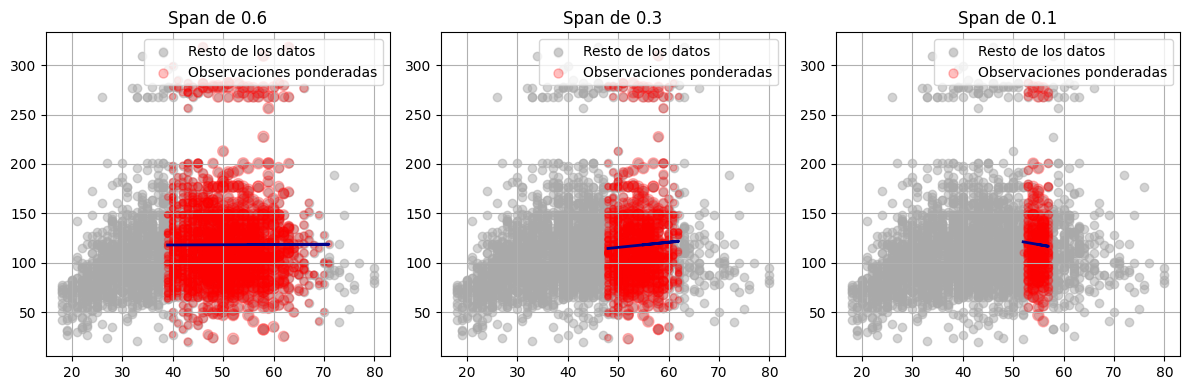

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(age, wage, alpha = 0.5, color = "darkgray", label = "Resto de los datos")
axes[0].scatter(local_agev[0], local_wagev[0], s=20 + 45*weightsv[0], alpha = 0.25, color = "red", label = f"Observaciones ponderadas")
axes[0].plot(local_agev[0], rectas[0], linewidth = 2, color="darkblue")
axes[0].set_title('Span de 0.6')
axes[0].grid(True)
axes[0].legend()

axes[1].scatter(age, wage, alpha = 0.5, color = "darkgray", label = "Resto de los datos")
axes[1].scatter(local_agev[1], local_wagev[1], s=20 + 45*weightsv[1], alpha = 0.25, color = "red", label = f"Observaciones ponderadas")
axes[1].plot(local_agev[1], rectas[1], linewidth = 2, color="darkblue")
axes[1].set_title('Span de 0.3')
axes[1].grid(True)
axes[1].legend()

axes[2].scatter(age, wage, alpha = 0.5, color = "darkgray", label = "Resto de los datos")
axes[2].scatter(local_agev[2], local_wagev[2], s=20 + 45*weightsv[2], alpha = 0.25, color = "red", label = f"Observaciones ponderadas")
axes[2].plot(local_agev[2], rectas[2], linewidth = 2, color="darkblue")
axes[2].set_title('Span de 0.1')
axes[2].grid(True)
axes[2].legend()


plt.tight_layout()


plt.show()

- ¿Qué ocurre con el tamaño del vecindario?

Mientras el span disminuye, el vecindario también lo hace.
- ¿Cómo cambia la recta local?

Su pendiente aumenta al disminuir el span.

**6.28.4 Ejercicio 4. Modelo global vs. local.** Ajusta:

- una regresión lineal global;

In [ ]:
X_global4 = sm.add_constant(age)
global_model4 = sm.OLS(wage, X_global4).fit()

- una regresión polinomial de grado 4;

In [ ]:
from ISLP.models import ModelSpec as MS, poly, summarize

design_g4 = MS([poly('age', degree=4)])
x_g4 = design_g4.fit_transform(Wage)
y4 = Wage['wage']

poly_model4 = sm.OLS(y4, x_g4).fit()

- un modelo LOWESS.

In [ ]:
fit4 = lowess(wage, age, frac=0.5)


Representa los tres ajustes sobre los mismos datos.

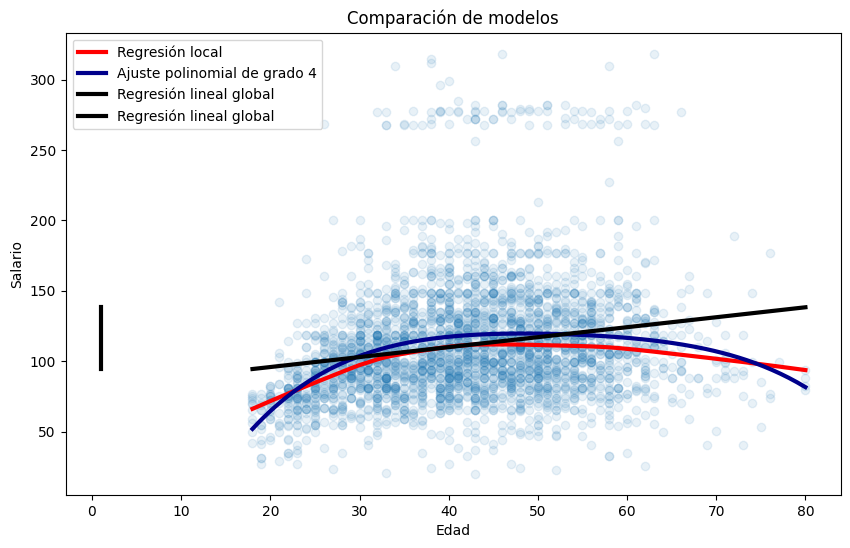

In [ ]:
age_grid5 = np.linspace(Wage['age'].min(), Wage['age'].max(), 200)
datos_pred5 = pd.DataFrame({'age': age_grid5})

X_pred5 = design_g4.transform(datos_pred5)
prediccion5 = poly_model4.get_prediction(X_pred5)

resumen_pred5 = prediccion5.summary_frame(alpha=0.05)

X_grid5 = sm.add_constant(age_grid5)
global_pred5 = global_model4.predict(X_grid5)

plt.figure(figsize = (10,6))

plt.scatter(age, wage, alpha = 0.1)

plt.plot(fit4[:,0], fit4[:,1], linewidth = 3, color = "red", label = "Regresión local")
plt.plot(age_grid5, resumen_pred5['mean'], lw=3, color = "darkblue", label = 'Ajuste polinomial de grado 4')
plt.plot(X_grid5, global_pred5, linewidth = 3, color = "black", label = "Regresión lineal global")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Comparación de modelos")
plt.legend()
plt.show()


Discute las principales diferencias entre las tres estrategias.

La regresión lineal global asume una relación lineal entre la variable independiente y la variable respuesta, por lo tanto, es poco flexible; no obstante, es fácil de interpretar. Por otro lado, la regresión polinomial de grado 4 modela una relación mediante un polinomio de grado 4, también de manera global; a diferencia del anterior, es mucho más flexible, aunque puede sobreajustar. Por último, LOWESS realiza ajustes locales ponderados a lo largo del dominio, permitiendo una flexibilidad mayor.

**6.28.5 Ejercicio 5. Selección del span.** Utiliza validación cruzada para comparar

$$
s \in {0.05, 0.10, 0.15, ..., 0.90}
$$

Determina el span que minimiza el MSE promedio de validación.

Finalmente, ajusta LOWESS utilizando ese span y representa el resultado

In [57]:
candidate_spans5 = np.linspace(0.05, 0.90, num=18)

In [58]:
kf5 = KFold(n_splits=5, shuffle = True, random_state=123)

X5 = age.to_numpy()  
y5 = wage.to_numpy()

In [62]:
cv_results5 = []

for span in candidate_spans5:

    fold_mse = []

    for train_idx, test_idx in kf.split(X):

        X_train = X5[train_idx]
        y_train = y5[train_idx]

        X_test = X5[test_idx]
        y_test = y5[test_idx]

        y_pred = lowess(
            y_train,
            X_train,
            frac=span,
            xvals=X_test
        )

        mse = mean_squared_error(
            y_test,
            y_pred
        )

        fold_mse.append(mse)

    cv_results5.append({
        "span": span,
        "MSE": np.mean(fold_mse)
    })

In [63]:
cv_results5 = pd.DataFrame(cv_results5)

cv_results5

,span,MSE
0,0.05,1638.657532
1,0.10,1635.867703
2,0.15,1634.416699
3,0.20,1633.581162
4,0.25,1633.880956
5,0.30,1634.965435
6,0.35,1636.724044
7,0.40,1638.400080
8,0.45,1640.371814
9,0.50,1642.713358


In [68]:
id_min = cv_results5["MSE"].idxmin()

In [70]:
span_min = cv_results5.loc[id_min, "span"]

In [72]:
fit_span_min = lowess(
    wage,
    age,
    frac=span_min
)

x_lowess5 = fit_span_min[:, 0]
y_lowess5 = fit_span_min[:, 1]

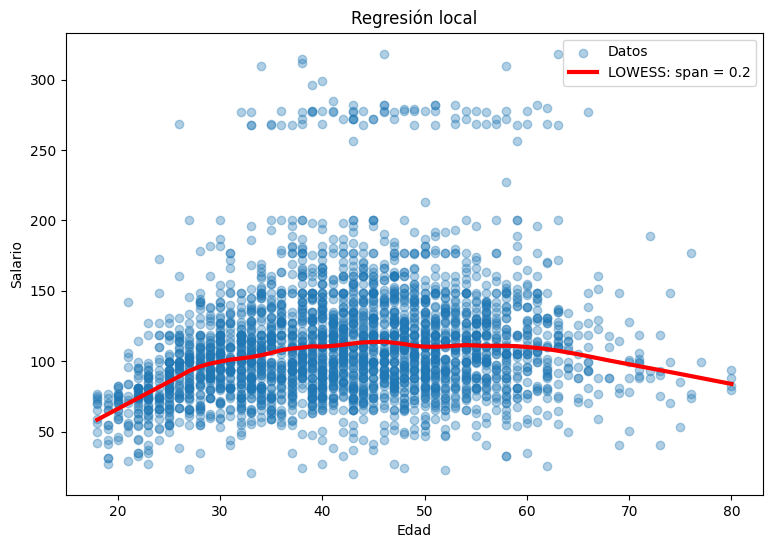

In [73]:
plt.figure(figsize=(9, 6))

plt.scatter(
    age,
    wage,
    alpha=0.35,
    label="Datos"
)

plt.plot(
    x_lowess5,
    y_lowess5,
    linewidth=3,
    color = "red",
    label="LOWESS: span = 0.2"
)

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Regresión local")
plt.legend()

plt.show()

**6.28.6 Ejercicio 6. Interpretación.** Explica con tus propias palabras por qué una colección de regresiones lineales locales puede producir una función global no lineal.

Tu explicación debe hacer referencia a:

- $x_0$;
- el vecindario;
- los pesos;
- $\hat{\beta_0}$;
- $\hat{\beta_1}$.

La regresión lineal local asigna pesos a las observaciones que están dentro de una vecindad de $x_0$, y ajusta una regresión lineal con $\hat{\beta_0}$ y $\hat{\beta_1}$ específicos para ese punto en particular. Como ésto se repite para todas las observaciones, entonces la unión de estos segmentos forman una curva más suave a nivel global.